# Model Analysis

This notebook does the following:

1. Loads VISUAL data from 4 mice. This data is composed of neural data + DINO features of videos.
2. Loads the trained models (cf. ModelGeneratorVISUAL.inpyb)
3. Compares embeddings.
4. Does a Neural Network Analysis composed of the following:
  - vizualization across layers of:
    - Single-Unit activation
    - CEBRA embedding across layers
    - t-SNE embeddings across layers
    - CKA
    - RDM



In [1]:
cd ../..

/Users/riccardocarpineto/Documents/CEBRA/t


In [67]:
import os
import pickle
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
'''import cebra.data
import cebra.datasets
import cebra.integrations'''
#from cebra import CEBRA

from tqdm import tqdm
from scipy.linalg import block_diag
from scipy.spatial.distance import cosine, correlation,cdist,pdist, squareform
from random import sample

from GithubFolder.src.preprocessing.CEBRA_preprocessing.plotting_utils import *
from GithubFolder.src.preprocessing.CEBRA_preprocessing.data_utils import *
from GithubFolder.src.preprocessing.CEBRA_preprocessing.quantification_utils import *

# Load the data

In [68]:
def add_gaussian_noise(neural_data, sigma: float = 2):
    gaussian_noise = torch.normal(mean=0.0, std=sigma, size=neural_data.size())
    return neural_data + gaussian_noise


def add_shot_noise(neural_data, scale_factor: float = 1.0):
    # Neural data * scale_factor = Poisson lambda
    return torch.poisson(neural_data * scale_factor) / scale_factor


In [69]:
train_datas, valid_datas, discrete_labels_train, discrete_labels_val = get_single_session_datasets()

shot_noise_levels= [0.2,0.5,0.7,1.0,1.2,1.5,2]
gaussian_noise_levels = [0.05, 0.1, 0.15,0.2,0.25,0.3,0.35]
poisson_noise_data = []
gaussian_noise_data = []

poisson_noise_data_train = []
gaussian_noise_data_train = []

for i in range(len(shot_noise_levels)):
     gaussian_noise_data.append(add_gaussian_noise(
            valid_datas[3].neural, sigma=gaussian_noise_levels[i]
        ))
     poisson_noise_data.append(add_shot_noise(
            valid_datas[3].neural, scale_factor=shot_noise_levels[i]
        ))
     
     gaussian_noise_data_train.append(add_gaussian_noise(
            train_datas[3].neural, sigma=gaussian_noise_levels[i]
        ))
     poisson_noise_data_train.append(add_shot_noise(
            train_datas[3].neural, scale_factor=shot_noise_levels[i]
        ))

all_train_data = [train_datas[3].neural] + poisson_noise_data_train + gaussian_noise_data_train
all_valid_data = [valid_datas[3].neural] + poisson_noise_data + gaussian_noise_data

# Load Models

In [70]:
models_folder_path = 'FinalModels/VISION'
files_list = os.listdir(models_folder_path)

models_list = []
for file in files_list: # load only the torch models for cpu usage
  if file.endswith("torch.pt"):
    models_list.append(file)

models_list
print('Number of models: ',len(models_list))
print(models_list)

Number of models:  12
['allen_single_session_mouse4_0k_UT_torch.pt', 'allen_multi_session_10k_3_torch.pt', 'allen_multi_session_10k_2_torch.pt', 'allen_single_session_mouse4_10k_0_torch.pt', 'allen_single_session_mouse4_10k_1_torch.pt', 'allen_multi_session_10k_4_torch.pt', 'allen_multi_session_10k_0_torch.pt', 'allen_multi_session_10k_1_torch.pt', 'allen_single_session_mouse4_10k_3_torch.pt', 'allen_single_session_mouse4_10k_2_torch.pt', 'allen_multi_session_0k_UT_torch.pt', 'allen_single_session_mouse4_10k_4_torch.pt']


In [71]:
models_untrained = [] # will be multi_ut, single_ut
models_single = [] # will be all the singles trained
models_multi = [] # will be all the multi trained


for model in models_list:

  loaded_model = cebra.CEBRA.load(os.path.join(models_folder_path,model), backend = 'torch', map_location=torch.device('cpu')).to('cpu')

  if 'UT' in model:
    models_untrained.append(loaded_model)

  elif 'multi' in model:
    models_multi.append(loaded_model)

  else:
    models_single.append(loaded_model)

1st step is to load all the 11 models:
- 1 Untrained:
- 5 Trained Single-session
- 5 Trained Multi-session

In [72]:
# check the models
print('# of Untrained models: ',len(models_untrained))
print('# of Single Trained models: ',len(models_single))
print('# of Single Trained models: ',len(models_multi))

print('Solver Untrained model 1: ',models_untrained[0].solver_name_) # HERE IT'S SINGLE SESSION FIRST
print('Solver Untrained model 2: ',models_untrained[1].solver_name_)
print(models_single[0].solver_name_)
print(models_multi[0].solver_name_)

# of Untrained models:  2
# of Single Trained models:  5
# of Single Trained models:  5
Solver Untrained model 1:  single-session
Solver Untrained model 2:  multi-session
single-session
multi-session


In [73]:
# example of a model
models_multi[0]

CEBRA(batch_size=2042, conditional='time_delta', device='cpu',
      model_architecture='offset10-model', output_dimension=128, temperature=1,
      time_offsets=10, verbose=True)

## Compare embeddings with noise

In [74]:
len(all_valid_data)

15

In [75]:
X = all_train_data
y = discrete_labels_train[3]
embeddings_single = []
embeddings_multi = []

for i in range(7):

    embeddings_single.append(models_single[0].transform(X[i*2]))
    embeddings_multi.append(models_multi[0].transform(X[i*2],session_id = 3))



# Align the single session embeddings to the first rat
alignment = cebra.data.helper.OrthogonalProcrustesAlignment()

for j in range(5):
    embeddings_single[j] = alignment.fit_transform(
        embeddings_single[0], embeddings_single[j], y, y)
    
for j in range(5):
    embeddings_multi[j] = alignment.fit_transform(
        embeddings_multi[0], embeddings_multi[j], y, y)



<Figure size 1000x600 with 0 Axes>

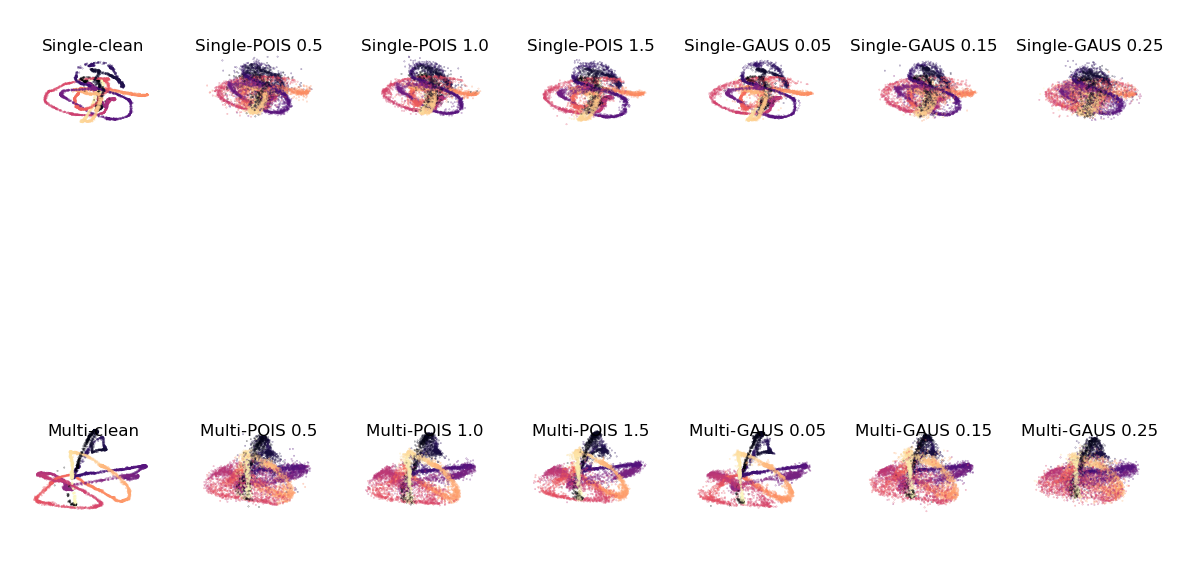

In [76]:
%matplotlib inline

num_layers = len(embeddings_single)

fig = plt.figure(figsize=(10,6))
fig, axs = plt.subplots(2, num_layers, figsize=(15, 10), subplot_kw={'projection': '3d'})

# Flatten the array of axes for easier indexing
axs = axs.flatten()

# Separate the axes into untrained and trained lists
axs_single = axs[:num_layers]
axs_multi = axs[num_layers:]

keys = ['clean'] + [f'POIS {i}' for i in shot_noise_levels] + [f'GAUS {i}' for i in gaussian_noise_levels]


i = 0
for  ax, ax_multi in zip( axs_single, axs_multi):

    embeddings_single_plot = embeddings_single[i]
    embeddings_multi_plot = embeddings_multi[i]
    title = keys[i*2]
    
    ax = plot_allen(ax, embeddings_single_plot, y)
    ax.set_title(f'Single-{title}', y=1, pad=-20)
    ax.axis('off')
    ax_multi = plot_allen(ax_multi, embeddings_multi_plot, y)
    ax_multi.set_title(f'Multi-{title}', y=1, pad=-20)
    ax_multi.axis('off')
    i += 1


plt.subplots_adjust(wspace=0,
                    hspace=0)
plt.show()

# MODEL EVALUATION

Here we get decoding of all the models to get understanding of our models and performance.

In [66]:
results = {}
keys = ['clean'] + [f'poisson {i}' for i in shot_noise_levels] + [f'gaussian {i}' for i in gaussian_noise_levels]

for j,key in enumerate(keys):
  results_untrained = np.zeros((len(models_untrained),3))
  results_single = np.zeros((len(models_single),3))
  results_multi = np.zeros((len(models_multi),3))

  # labels
  label_train = y
  label_test = discrete_labels_val[3]

  #data
  data_train = all_train_data[j]
  data_test = all_valid_data[j]

  # UNTRAINED
  for i,model in enumerate(models_untrained):
    if i == 1: # multi session, need to add the session id
      train = model.transform(data_train, session_id = 3)
      test = model.transform(data_test, session_id = 3)
    else:
      train = model.transform(data_train)
      test = model.transform(data_test)

    results_untrained[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)



  # SINGLE
  for i,model in enumerate(models_single):
    train = model.transform(data_train)
    test = model.transform(data_test)
    results_single[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)

  # MULTI
  for i,model in enumerate(models_multi):
    train = model.transform(data_train, session_id=3)
    test = model.transform(data_test, session_id=3)
    results_multi[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)

  mean_results_untrained = np.mean(results_untrained, axis = 0)
  mean_results_single = np.mean(results_single, axis = 0)
  mean_results_multi = np.mean(results_multi, axis = 0)

  results[key] = [mean_results_untrained,mean_results_single,mean_results_multi]


In [77]:
results = pd.DataFrame(columns=['Noise', 'UT_acc','Single_acc','Multi_acc'])

noises = ['clean'] + [f'poisson {i}' for i in shot_noise_levels] + [f'gaussian {i}' for i in gaussian_noise_levels]

for j in tqdm(range(len(noises))):
  results_untrained = np.zeros((len(models_untrained),3))
  results_single = np.zeros((len(models_single),3))
  results_multi = np.zeros((len(models_multi),3))

  # labels
  label_train = y
  label_test = discrete_labels_val[3]

  #data
  data_train = all_train_data[j]
  data_test = all_valid_data[j]

  # UNTRAINED
  for i,model in enumerate(models_untrained):
    if i == 1: # multi session, need to add the session id
      train = model.transform(data_train, session_id = 3)
      test = model.transform(data_test, session_id = 3)
    else:
      train = model.transform(data_train)
      test = model.transform(data_test)

    results_untrained[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)



  # SINGLE
  for i,model in enumerate(models_single):
    train = model.transform(data_train)
    test = model.transform(data_test)
    results_single[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)

  # MULTI
  for i,model in enumerate(models_multi):
    train = model.transform(data_train, session_id=3)
    test = model.transform(data_test, session_id=3)
    results_multi[i] = decoding_frames(embedding_train=train,label_train=label_train,embedding_test=test, label_test=label_test)

  mean_results_untrained = np.mean(results_untrained, axis = 0)
  mean_results_single = np.mean(results_single, axis = 0)
  mean_results_multi = np.mean(results_multi, axis = 0)

  new_row = pd.DataFrame({
      'Noise': [noises[j]],
      'UT_acc': [mean_results_untrained[2]],
      'Single_acc': [mean_results_single[2]],
      'Multi_acc': [mean_results_multi[2]]
  })

  # Concatenate the new row to the results DataFrame
  results = pd.concat([results, new_row], ignore_index=True)


  0%|          | 0/15 [00:00<?, ?it/s]/var/folders/cz/0t4gl6_n38s_lcm5kjk5jw0m0000gn/T/ipykernel_53629/226794963.py:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)
100%|██████████| 15/15 [05:55<00:00, 23.71s/it]


In [79]:
df = results.copy()

# Separate rows based on noise type
poisson_rows = df[df['Noise'].str.contains('poisson')]
other_rows = df[~df['Noise'].str.contains('poisson')]

# Extract numerical part from 'poisson' rows and sort them in descending order
poisson_rows['Poisson_Value'] = poisson_rows['Noise'].str.extract(r'(\d+\.\d+)').astype(float)
poisson_rows_sorted = poisson_rows.sort_values(by='Poisson_Value', ascending=False)

# Drop the 'Poisson_Value' column after sorting
poisson_rows_sorted = poisson_rows_sorted.drop(columns='Poisson_Value')

# Concatenate the sorted poisson rows with the other rows
final_df = pd.concat([other_rows, poisson_rows_sorted], ignore_index=True)

# Display the reordered DataFrame
print(final_df)


            Noise     UT_acc  Single_acc  Multi_acc
0           clean  19.166667   78.066667  66.155556
1   gaussian 0.05  17.000000   76.088889  62.844444
2    gaussian 0.1  14.555556   69.911111  62.733333
3   gaussian 0.15  13.055556   61.222222  53.622222
4    gaussian 0.2  10.944444   56.222222  47.800000
5   gaussian 0.25   9.000000   48.711111  39.644444
6    gaussian 0.3   8.833333   44.622222  38.200000
7   gaussian 0.35   8.000000   36.844444  31.688889
8     poisson 1.5  15.111111   72.622222  61.755556
9     poisson 1.2  13.500000   69.755556  61.600000
10    poisson 1.0  16.444444   68.511111  59.622222
11    poisson 0.7  13.333333   62.688889  56.266667
12    poisson 0.5  14.388889   58.266667  52.488889
13    poisson 0.2  14.000000   40.711111  33.000000
14      poisson 2  15.222222   70.755556  63.066667


/var/folders/cz/0t4gl6_n38s_lcm5kjk5jw0m0000gn/T/ipykernel_53629/1648861813.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poisson_rows['Poisson_Value'] = poisson_rows['Noise'].str.extract(r'(\d+\.\d+)').astype(float)


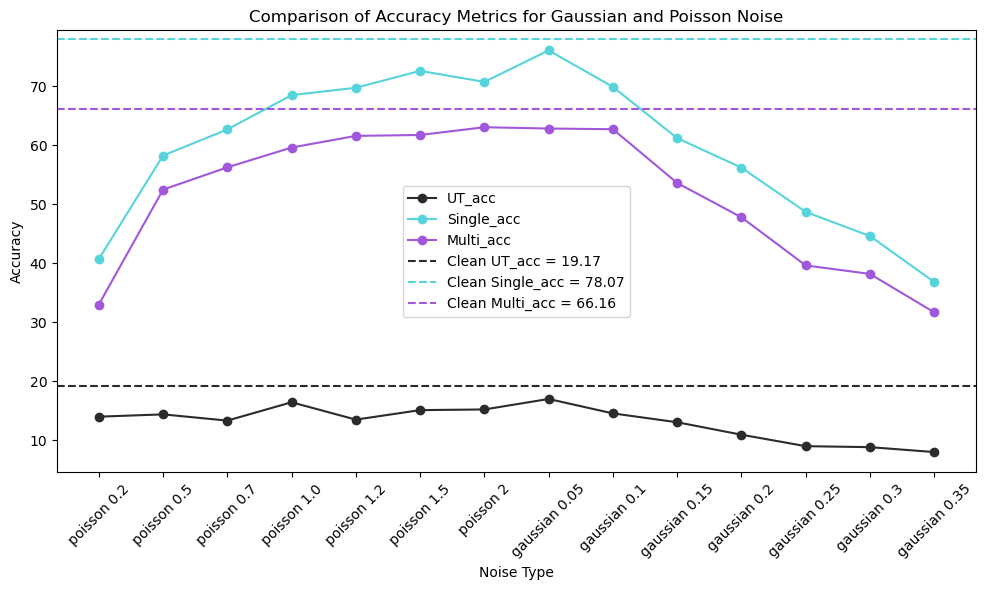

In [83]:

colors = sns.color_palette("hls",8)
pastel_purple = colors[6]
pastel_blue = colors[4]
grey = sns.color_palette("Greys")[5]

# Extract clean row value for comparison
clean_row = df[df['Noise'] == 'clean'].iloc[0]

# Filter out gaussian and poisson rows
gaussian_poisson_df = df[df['Noise'].str.contains('gaussian|poisson')]

# Plotting
plt.figure(figsize=(10, 6))

# Plot UT_acc, Single_acc, and Multi_acc for gaussian and poisson
plt.plot(gaussian_poisson_df['Noise'], gaussian_poisson_df['UT_acc'], label='UT_acc', marker='o', color=grey)
plt.plot(gaussian_poisson_df['Noise'], gaussian_poisson_df['Single_acc'], label='Single_acc', marker='o', color=pastel_blue)
plt.plot(gaussian_poisson_df['Noise'], gaussian_poisson_df['Multi_acc'], label='Multi_acc', marker='o', color=pastel_purple)

# Add horizontal lines for no noise values
plt.axhline(y=clean_row['UT_acc'], color=grey, linestyle='--', label=f"Clean UT_acc = {clean_row['UT_acc']:.2f}")
plt.axhline(y=clean_row['Single_acc'], color=pastel_blue, linestyle='--', label=f"Clean Single_acc = {clean_row['Single_acc']:.2f}")
plt.axhline(y=clean_row['Multi_acc'], color=pastel_purple, linestyle='--', label=f"Clean Multi_acc = {clean_row['Multi_acc']:.2f}")

plt.xlabel('Noise Type')
plt.ylabel('Accuracy')
plt.title('Comparison of Accuracy Metrics for Gaussian and Poisson Noise')
plt.xticks(rotation=45)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()
